## Week - 11 Demand Forecasting [Store Sales Prediction]

* Nowadays, shopping malls and Big Marts keep track of individual items sales data in order to forecast future client demand and adjust inventory management. In a data warehouse, these data stores hold a significant amount of consumer information and particular item details. By mining the data store from the data warehouse, more anomalies and patterns can be discovered.

### Store Sales Prediction as a Demand Forecasting Usecase?

**Store sales prediction is a demand forecasting usecase in manufacturing indust. By analyzing store sales data, manufacturers can gain insights into customer demand patterns, which can help to inform production and inventory decisions. For example, a manufacturer may analyze store sales data to determine which products are selling well and which products are not, and then adjust production schedules and inventory levels accordingly. This can help the manufacturer to better manage stock levels, reduce waste, and ensure that popular products are always in stock. By using store sales data as part of a demand forecasting process, manufacturers can make more informed decisions that ultimately lead to improved business performance.**

## AI Project Cycle 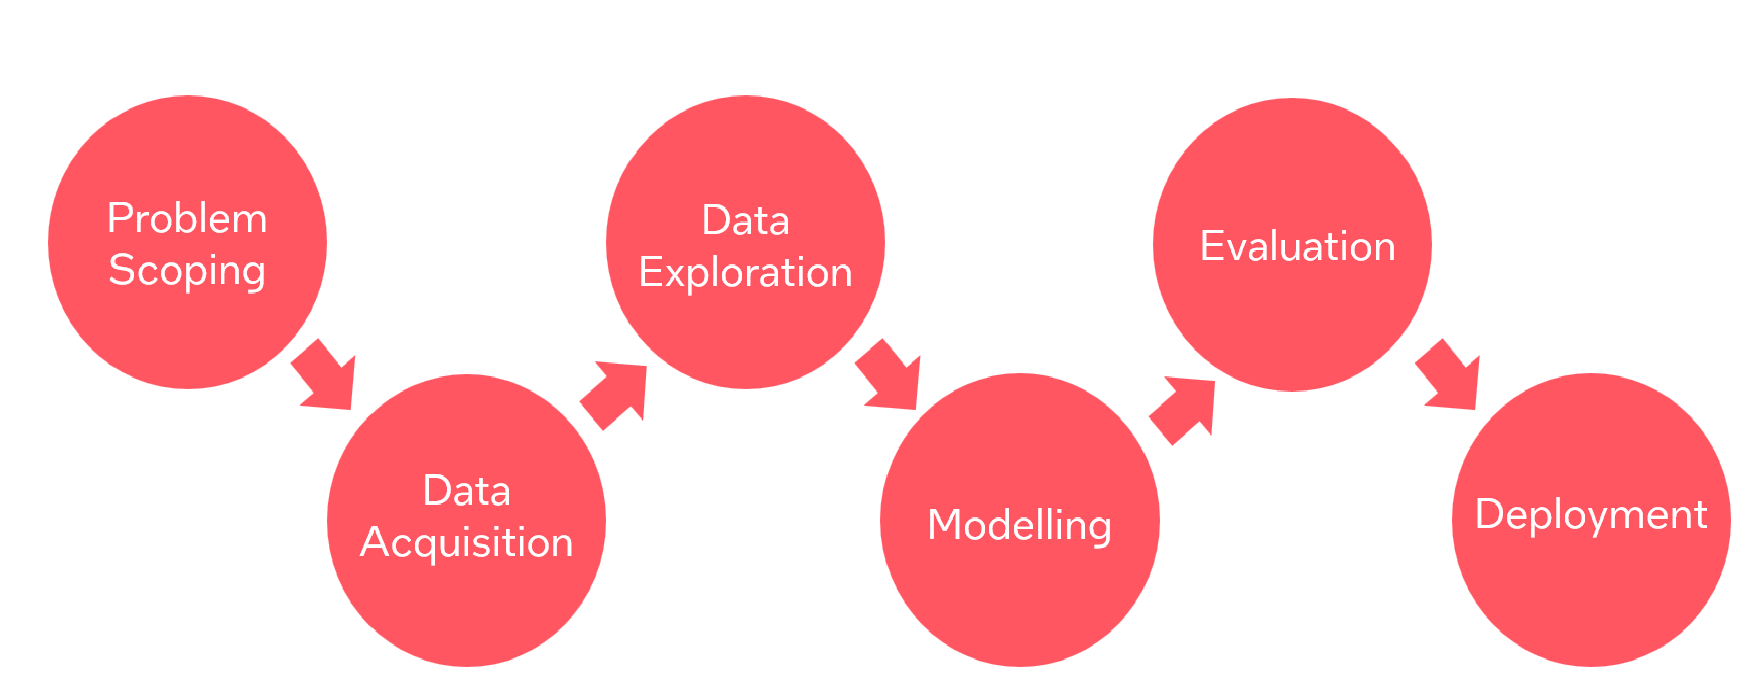

## Context: Understanding the Problem Statement --------Problem Scoping (AI Project Cycle - Step 1)

Nowadays, shopping malls and Big Marts keep track of individual items sales data in order to forecast future client demand and adjust inventory management. In a data warehouse, these data stores hold a significant amount of consumer information and particular item details. By mining the data store from the data warehouse, more anomalies and patterns can be discovered.

The classical machine learning tasks like Data Exploration, Data Cleaning, Feature Engineering, Model Building and Model Testing. Try out different machine learning algorithms that's best fit for the above case.

### Import the useful Packages & Libraries

In [1]:
%pip install ipython-autotime
%load_ext autotime

Note: you may need to restart the kernel to use updated packages.
time: 98.7 μs (started: 2026-10-06 16:58:25 -07:00)


In [2]:
# if not already, install matplotlib seaborn plotly

time: 1.02 ms (started: 2026-10-06 16:58:25 -07:00)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings(action="ignore")
#plt.style.use(["seaborn-bright","dark_background"])

time: 2.39 s (started: 2026-10-06 16:58:25 -07:00)


To know more about Plotly click [here](https://plotly.com/python/)

## Dataset:  Data Acquisition (AI Project Cycle - Step 2)

`Data is taken from kaggle which is a Store Sales Dataset.`

Source - https://www.kaggle.com/datasets/brijbhushannanda1979/bigmart-sales-data

### Load/Read the Dataset

In [4]:
# Load the data
train = pd.read_csv("Data11/Train.csv")
test = pd.read_csv("Data11/Test.csv")

time: 42.6 ms (started: 2026-10-06 16:58:27 -07:00)


### View the data

In [5]:
#Prints the first five entry of the dataframe
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


time: 27 ms (started: 2026-10-06 16:58:27 -07:00)


In [6]:
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


time: 16.9 ms (started: 2026-10-06 16:58:27 -07:00)


In [7]:
#It shows the number of rows and columns of the given dataframe
train.shape

(8523, 12)

time: 3.02 ms (started: 2026-10-06 16:58:27 -07:00)


In [8]:
#It shows the number of rows and columns of the given dataframe
test.shape

(5681, 11)

time: 3.29 ms (started: 2026-10-06 16:58:27 -07:00)


**- We have train(8523) and test(5681) data set, train data set has both input and output variables.**

### Attribute Information-

### `Features:`

**Item_weight** : Weight of product

**Item_Fat_Content** : Whether the product is low fat or not

**Item_Visibility** : The % of total display area of all products in a store allocated to a particular product.

**Item_Type** : The category to which the product belongs

**Item_MRP** : Maximum Retail Price (list price) of the product

**Outlet_Identifier** : Unique Store ID

**Outlet_Establishment_Year** : The year in which store was established

**Outlet_Size** : The size of the store in terms of ground area covered

**Outlet_Location_Type** : The type of city in which the store is located

**Outlet_Type** : Whether the outlet is just a grocery store or some sort of supermarket

### `Target:`

**Item_Outlet_Sales** : Sales of the product in the particular store. This is the outcome variable to be predicted.

## Data Preprocessing ------ Data Exploration(AI Project Cycle - Step 3)

### View the information of data

In [9]:
# info() helps summarize the dataset- It gives basic information like number of non-null values, datatypes and memory usage
# It is a good practise to start by this information
train.info() 

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB
time: 17 ms (started: 2026-10-06 16:58:27 -07:00)


In [10]:
# info() helps summarize the dataset- It gives basic information like number of non-null values, datatypes and memory usage
# It is a good practise to start by this information

# Write code to illustrate the information about test dataset

time: 1.4 ms (started: 2026-10-06 16:58:27 -07:00)


### Check the number of rows and columns of the dataset

In [11]:
#It returns the column names of the given dataframe
train.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

time: 3.48 ms (started: 2026-10-06 16:58:27 -07:00)


In [12]:
#It returns the column names of the given dataframe
test.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='str')

time: 4.4 ms (started: 2026-10-06 16:58:27 -07:00)


In [13]:
#It gives the numerical statistical information of the dataframe
"""
count - The number of non-empty values.
mean - The average value
std - The standard deviation
min - the minimum value
25% - The 25% percentile*
50% - The 50% percentile*
75% - The 75% percentile*
max - the maximum value """

train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


time: 33.1 ms (started: 2026-10-06 16:58:27 -07:00)


In [14]:
test.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


time: 28.4 ms (started: 2026-10-06 16:58:27 -07:00)


### Find the total number of missing values feature wise

In [15]:
#It returns the number of null values in the dataframe for every column feature
#Using info() we can view the number of non-null values whereas isnull() gives the number of null values
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

time: 17 ms (started: 2026-10-06 16:58:27 -07:00)


We have 17% and 28% of missing values in Item weight and Outlet_Size columns respectively.

**Why missing values treatment is required?**

Missing data in the training data set can reduce the power / fit of a model or can lead to a biased model because we have not analysed the behavior and relationship with other variables correctly. It can lead to wrong prediction.

In [16]:
#Checking if there is any gender imbalance in dataframe
train['Outlet_Size'].value_counts() 

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

time: 11.7 ms (started: 2026-10-06 16:58:27 -07:00)


Since the outlet_size is a categorical column, we can impute the missing values by "Mode"(Most Repeated Value) from the column.

In [17]:
train["Outlet_Size"] = train["Outlet_Size"].fillna(train["Outlet_Size"].mode())

time: 5.4 ms (started: 2026-10-06 16:58:27 -07:00)


In [18]:
group = train.groupby("Item_Type")["Item_Weight"].mean()
group

Item_Type
Baking Goods             12.277108
Breads                   11.346936
Breakfast                12.768202
Canned                   12.305705
Dairy                    13.426069
Frozen Foods             12.867061
Fruits and Vegetables    13.224769
Hard Drinks              11.400328
Health and Hygiene       13.142314
Household                13.384736
Meat                     12.817344
Others                   13.853285
Seafood                  12.552843
Snack Foods              12.987880
Soft Drinks              11.847460
Starchy Foods            13.690731
Name: Item_Weight, dtype: float64

time: 14 ms (started: 2026-10-06 16:58:27 -07:00)


In [19]:
for i in range(len(group)):
    g = (train['Item_Type'] == group.index[i]) & (train['Item_Weight'].isna() == True)
    train['Item_Weight'] = np.select([g], [group.iloc[i]], train['Item_Weight'])

time: 45.2 ms (started: 2026-10-06 16:58:27 -07:00)


In [20]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857890,0.066132,140.992782,1997.831867,2181.288914
std,4.232804,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.867061,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


time: 42.2 ms (started: 2026-10-06 16:58:28 -07:00)


In [21]:
fig = px.box(train, x = "Item_Outlet_Sales",height=400,width=700)
#fig.show()
fig.show(renderer="browser")

time: 742 ms (started: 2026-10-06 16:58:28 -07:00)


In [22]:
q1 = train["Item_Outlet_Sales"].quantile(0.25)
q3 = train["Item_Outlet_Sales"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3+1.5*iqr

time: 12.9 ms (started: 2026-10-06 16:58:28 -07:00)


In [23]:
group1 = train.groupby("Item_Type")["Item_Outlet_Sales"].mean()
group1

Item_Type
Baking Goods             1952.971207
Breads                   2204.132226
Breakfast                2111.808651
Canned                   2225.194904
Dairy                    2232.542597
Frozen Foods             2132.867744
Fruits and Vegetables    2289.009592
Hard Drinks              2139.221622
Health and Hygiene       2010.000265
Household                2258.784300
Meat                     2158.977911
Others                   1926.139702
Seafood                  2326.065928
Snack Foods              2277.321739
Soft Drinks              2006.511735
Starchy Foods            2374.332773
Name: Item_Outlet_Sales, dtype: float64

time: 40.2 ms (started: 2026-10-06 16:58:28 -07:00)


In [24]:
for i in range(len(group1)):
    g = (train['Item_Type'] == group1.index[i]) & (train['Item_Outlet_Sales'] > upper_bound)
    train['Item_Outlet_Sales'] = np.select([g], [group1.iloc[i]], train['Item_Outlet_Sales'])

time: 54.8 ms (started: 2026-10-06 16:58:29 -07:00)


In [25]:
for i in train.columns:
    if train[i].dtype=="object":
        print("{} has unique values {}".format(i,train[i].unique()))

time: 2.25 ms (started: 2026-10-06 16:58:29 -07:00)


**`Every dataset consists of some missing values and outliers. The categorical missing values are filled with most frequent value i.e. mode while the numeric values are filled with mean. Also the outliers are treated with the mean value correspoiding to their item type.`**

### `Feature Encoding`

We use one-hot encoding to convert categorical features to numeric data. For more info on one hot encoding clic [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

Since the outlet_size is a categorical column, we can impute the missing values by "Mode"(Most Repeated Value) from the column.

In [26]:
train["Item_Fat_Content"] = train["Item_Fat_Content"].replace(['Low Fat','Regular','low fat','LF','reg'],
                                                              ['Low Fat','Regular','Low Fat','Low Fat','Regular'])

time: 14.9 ms (started: 2026-10-06 16:58:29 -07:00)


In [27]:
train["Item_Type"] = train["Item_Type"].replace(['Dairy','Soft Drinks','Meat','Fruits and Vegetables',
                                                 'Household','Baking Goods','Snack Foods','Frozen Foods',
                                                 'Breakfast','Health and Hygiene','Hard Drinks','Canned',
                                                 'Breads','Starchy Foods','Others','Seafood'],
                                               ['Food','Drinks','Food','Food',
                                                 'Others','Others','Food','Food',
                                                 'Food','Others','Drinks','Food',
                                                 'Food','Food','Others','Food'])

time: 28.5 ms (started: 2026-10-06 16:58:29 -07:00)


In [28]:
train["Outlet_Location_Type"] = train["Outlet_Location_Type"].replace(['Tier 1','Tier 3','Tier 2'],
                                                                      [1,3,2])

time: 14.6 ms (started: 2026-10-06 16:58:29 -07:00)


### `Data Visualizations`

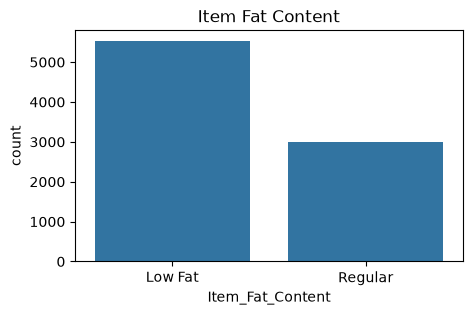

time: 214 ms (started: 2026-10-06 16:58:29 -07:00)


In [29]:
plt.figure(figsize=(5,3))
sns.countplot(x = "Item_Fat_Content", data = train)
plt.title("Item Fat Content")
plt.show()

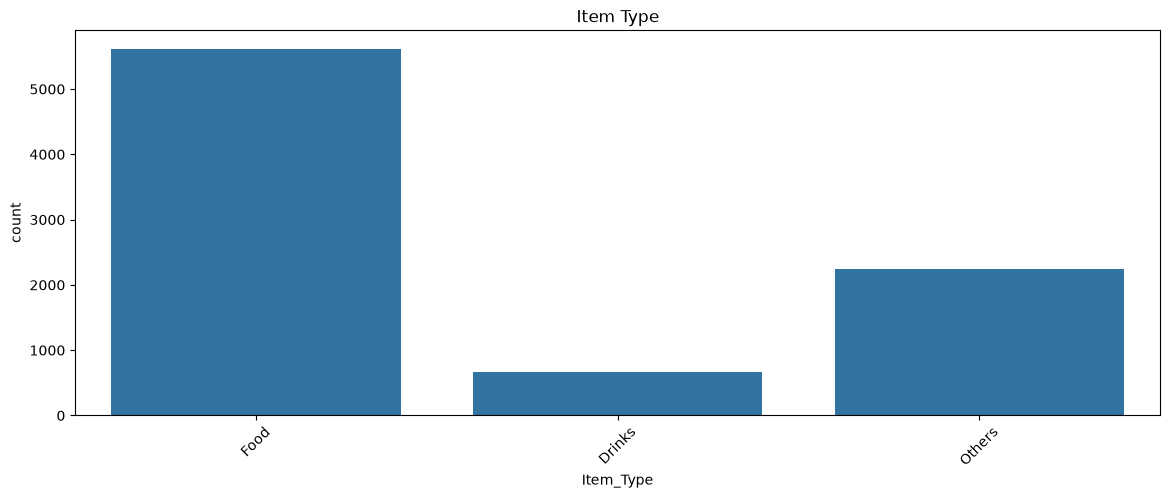

time: 193 ms (started: 2026-10-06 16:58:29 -07:00)


In [30]:
plt.figure(figsize=(14,5))
sns.countplot(x = "Item_Type", data = train)
plt.title("Item Type")
plt.xticks(rotation=45)
plt.show()

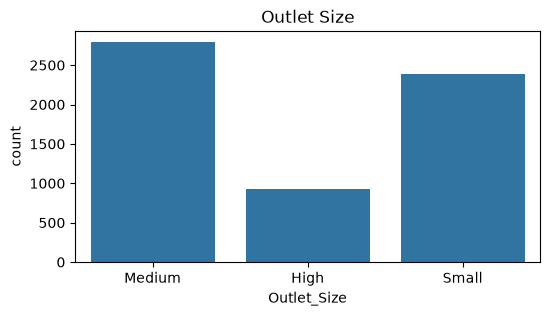

time: 180 ms (started: 2026-10-06 16:58:29 -07:00)


In [31]:
plt.figure(figsize=(6,3))
sns.countplot(x = "Outlet_Size", data = train)
plt.title("Outlet Size")
plt.show()

In [32]:
train["sqr_Item_Outlet_Sales"] = np.sqrt(train["Item_Outlet_Sales"])

time: 5.85 ms (started: 2026-10-06 16:58:29 -07:00)


In [33]:
train.columns,train.shape

(Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
        'Item_Type', 'Item_MRP', 'Outlet_Identifier',
        'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
        'Outlet_Type', 'Item_Outlet_Sales', 'sqr_Item_Outlet_Sales'],
       dtype='str'),
 (8523, 13))

time: 6.21 ms (started: 2026-10-06 16:58:29 -07:00)


### `Correlation Heatmap`

To know more about heatmap click [here](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

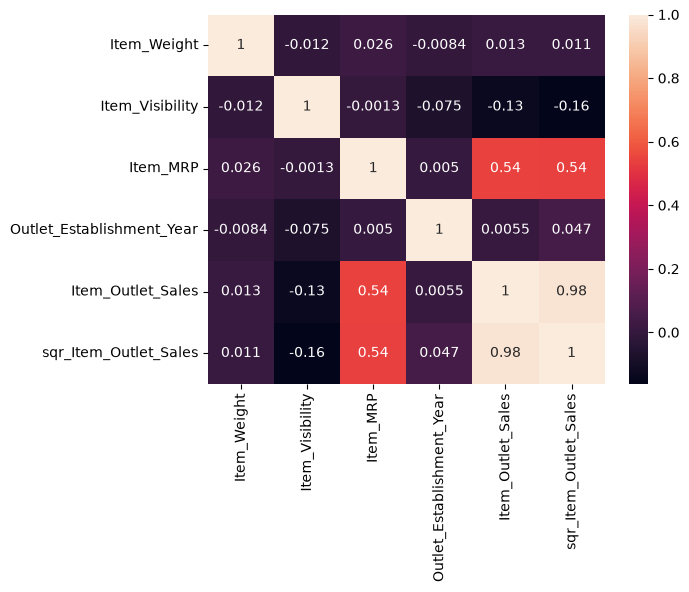

time: 477 ms (started: 2026-10-06 16:58:30 -07:00)


In [34]:
sns.heatmap(train.corr(numeric_only=True),annot=True)
plt.show()

A correlation coefficient of 0.5 indicates a moderate positive linear relationship between two variables. This means that as one variable increases, the other variable tends to increase as well.

In [35]:
train["cbr_Item_Visibility"] = np.cbrt(train["Item_Visibility"])

time: 2.96 ms (started: 2026-10-06 16:58:30 -07:00)


### `One-Hot Encoding`

In [36]:
category_col = ['Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Type']

time: 1.43 ms (started: 2026-10-06 16:58:30 -07:00)


In [37]:
train = pd.get_dummies(train,columns=category_col,drop_first=False)

time: 19.8 ms (started: 2026-10-06 16:58:30 -07:00)


In [38]:
train.drop(columns=["Item_Identifier","Outlet_Identifier","Outlet_Establishment_Year","sqr_Item_Outlet_Sales","Item_Visibility"],inplace=True)

time: 3.02 ms (started: 2026-10-06 16:58:30 -07:00)


In [39]:
train.to_csv("Data11/modified_train.csv",index=False)

time: 187 ms (started: 2026-10-06 16:58:30 -07:00)


In [40]:
# Write code to print training dataframe

time: 984 μs (started: 2026-10-06 16:58:30 -07:00)


### `Working on test data same as we work on train data`

In [41]:
for i in test.columns:
    per = test[i].isnull().sum()/len(test)
    print("Feature {} has {}% data missing".format(i,round(per*100,3)))

Feature Item_Identifier has 0.0% data missing
Feature Item_Weight has 17.18% data missing
Feature Item_Fat_Content has 0.0% data missing
Feature Item_Visibility has 0.0% data missing
Feature Item_Type has 0.0% data missing
Feature Item_MRP has 0.0% data missing
Feature Outlet_Identifier has 0.0% data missing
Feature Outlet_Establishment_Year has 0.0% data missing
Feature Outlet_Size has 28.27% data missing
Feature Outlet_Location_Type has 0.0% data missing
Feature Outlet_Type has 0.0% data missing
time: 11.2 ms (started: 2026-10-06 16:58:30 -07:00)


In [42]:
test["Outlet_Size"] = test["Outlet_Size"].fillna(test["Outlet_Size"].mode())

time: 6.73 ms (started: 2026-10-06 16:58:30 -07:00)


In [43]:
for i in range(len(group)):
    g = (test['Item_Type'] == group.index[i]) & (test['Item_Weight'].isna() == True)
    test['Item_Weight'] = np.select([g], [group.iloc[i]], test['Item_Weight'])

time: 70.5 ms (started: 2026-10-06 16:58:30 -07:00)


In [44]:
test["Item_Fat_Content"] = test["Item_Fat_Content"].replace(['Low Fat','Regular','low fat','LF','reg'],
                                                              ['Low Fat','Regular','Low Fat','Low Fat','Regular'])

time: 12.3 ms (started: 2026-10-06 16:58:31 -07:00)


In [45]:
test["Item_Type"] = test["Item_Type"].replace(['Dairy','Soft Drinks','Meat','Fruits and Vegetables',
                                                 'Household','Baking Goods','Snack Foods','Frozen Foods',
                                                 'Breakfast','Health and Hygiene','Hard Drinks','Canned',
                                                 'Breads','Starchy Foods','Others','Seafood'],
                                               ['Food','Drinks','Food','Food',
                                                 'Others','Others','Food','Food',
                                                 'Food','Others','Drinks','Food',
                                                 'Food','Food','Others','Food'])

time: 26.8 ms (started: 2026-10-06 16:58:31 -07:00)


In [46]:
test["Outlet_Location_Type"] = test["Outlet_Location_Type"].replace(['Tier 1','Tier 3','Tier 2'],
                                                                      [1,3,2])

time: 6.07 ms (started: 2026-10-06 16:58:31 -07:00)


In [47]:
test["cbr_Item_Visibility"] = np.cbrt(test["Item_Visibility"])

time: 2.74 ms (started: 2026-10-06 16:58:31 -07:00)


In [48]:
test = pd.get_dummies(test,columns=category_col,drop_first=False)

time: 16.8 ms (started: 2026-10-06 16:58:31 -07:00)


In [49]:
test.drop(columns=["Item_Identifier","Outlet_Identifier","Outlet_Establishment_Year","Item_Visibility"],inplace=True)

time: 2.75 ms (started: 2026-10-06 16:58:31 -07:00)


In [50]:
X = train.drop(columns=["Item_Outlet_Sales"])

time: 7.23 ms (started: 2026-10-06 16:58:31 -07:00)


In [51]:
test = test[X.columns]

time: 6.38 ms (started: 2026-10-06 16:58:31 -07:00)


In [52]:
test.to_csv("Data11/modified_test.csv",index=False)

time: 60.3 ms (started: 2026-10-06 16:58:31 -07:00)


In [53]:
test.head()

,Item_Weight,Item_MRP,Outlet_Location_Type,cbr_Item_Visibility,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Drinks,Item_Type_Food,Item_Type_Others,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,20.750000,107.8622,1,0.196306,True,False,False,True,False,False,True,False,False,True,False,False
1,8.300000,87.3198,2,0.337454,False,True,False,True,False,False,False,False,False,True,False,False
2,14.600000,241.7538,3,0.463500,True,False,False,False,True,False,False,False,True,False,False,False
3,7.315000,155.0340,2,0.248732,True,False,False,True,False,False,False,False,False,True,False,False
4,13.426069,234.2300,3,0.491316,False,True,False,True,False,False,True,False,False,False,False,True


time: 23.3 ms (started: 2026-10-06 16:58:31 -07:00)


### Splitting the dataframe into independent(features) and dependent features(targets)


In [54]:
train = pd.read_csv("Data11/modified_train.csv")
test = pd.read_csv("Data11/modified_test.csv")

time: 82.5 ms (started: 2026-10-06 16:58:31 -07:00)


In [55]:
X = train.drop(columns=["Item_Outlet_Sales"])
y = train["Item_Outlet_Sales"]

time: 3.61 ms (started: 2026-10-06 16:58:31 -07:00)


In [56]:
from sklearn.model_selection import train_test_split
x_train, x_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=101)

time: 433 ms (started: 2026-10-06 16:58:31 -07:00)


## Building a Model ------ Modeling ( AI Project Cycle - Step 4)

To learn more about the sklearn evaluation matrices click [here](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [57]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import time

time: 1.56 ms (started: 2026-10-06 16:58:32 -07:00)


In [58]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

time: 234 ms (started: 2026-10-06 16:58:32 -07:00)


In [59]:
models = []
models.append(("LinearRegressor",LinearRegression()))
models.append(("Lasso",Lasso()))
models.append(("Ridge",Ridge()))
models.append(("DecisionTree",DecisionTreeRegressor()))
models.append(("RandomForestRegressor",RandomForestRegressor()))
models.append(("ExtraTreeRegressor",ExtraTreesRegressor()))
models.append(("AdaBoostRegressor",AdaBoostRegressor()))
models.append(("GradientBoosingRegressor",GradientBoostingRegressor()))
models.append(("SVR",SVR()))
models.append(("KNeighborsRegressor",KNeighborsRegressor()))

time: 3.76 ms (started: 2026-10-06 16:58:32 -07:00)


## Evaluating the Model ------- Evaluation (AI Project Cycle - Step 5)

In [60]:
names = []
score = []
rmse = []
mse = []
mae = []
r2 = []
timing = []

time: 125 ms (started: 2026-10-06 16:58:32 -07:00)


In [61]:
for name,model in models:
    model = model
    beg = time.time()
    model.fit(x_train,y_train)
    pred = model.predict(x_valid)
    end = time.time()
    print("Model = {}".format(name))
    print("Score = {}, RMSE = {}, MSE = {}, MAE = {}, R2 = {},Time = {}\n".format(round(model.score(x_valid,y_valid),4),
                                                round(np.sqrt(mean_squared_error(pred,y_valid)),4),
                                                round(mean_squared_error(pred,y_valid),4),
                                                round(mean_absolute_error(pred,y_valid),4),
                                                round(r2_score(y_valid,pred),4),(end-beg)))
    names.append(name)
    score.append(round(model.score(x_valid,y_valid),4))
    rmse.append(round(np.sqrt(mean_squared_error(pred,y_valid)),4))
    mse.append(round(mean_squared_error(pred,y_valid),4))
    mae.append(round(mean_absolute_error(pred,y_valid),4))
    r2.append(round(r2_score(pred,y_valid),4))
    timing.append(end-beg)

Model = LinearRegressor
Score = 0.5206, RMSE = 1029.5462, MSE = 1059965.435, MAE = 791.8425, R2 = 0.5206,Time = 0.011135101318359375

Model = Lasso
Score = 0.5207, RMSE = 1029.4332, MSE = 1059732.8016, MAE = 791.6892, R2 = 0.5207,Time = 0.006826162338256836

Model = Ridge
Score = 0.5206, RMSE = 1029.5423, MSE = 1059957.2803, MAE = 791.845, R2 = 0.5206,Time = 0.0054781436920166016

Model = DecisionTree
Score = 0.0514, RMSE = 1448.2749, MSE = 2097500.1175, MAE = 1031.009, R2 = 0.0514,Time = 0.0448911190032959

Model = RandomForestRegressor
Score = 0.486, RMSE = 1066.147, MSE = 1136669.3879, MAE = 766.3479, R2 = 0.486,Time = 2.812385320663452

Model = ExtraTreeRegressor
Score = 0.4487, RMSE = 1104.1443, MSE = 1219134.5303, MAE = 795.0229, R2 = 0.4487,Time = 2.0628879070281982

Model = AdaBoostRegressor
Score = 0.5197, RMSE = 1030.6043, MSE = 1062145.2929, MAE = 777.8057, R2 = 0.5197,Time = 0.20270180702209473

Model = GradientBoosingRegressor
Score = 0.5548, RMSE = 992.1315, MSE = 984324.

In [62]:
df = pd.DataFrame()
df["names"] = names
df["Score"] = score
df["time"] = timing
df["rmse"] = rmse
df["mse"] = mse
df["mae"] = mae
df["r2"] = r2

time: 6.46 ms (started: 2026-10-06 16:58:44 -07:00)


In [63]:
df = df.sort_values(by="Score",ascending=False)
fig = px.bar(df,"names","Score",color="names",title="Accuracy Score")
#fig.show()
fig.show(renderer="browser")

time: 443 ms (started: 2026-10-06 16:58:44 -07:00)


In [64]:
# Write code to plot the RMSE values of each model here.

time: 2.64 ms (started: 2026-10-06 16:58:45 -07:00)


In [65]:
# Write code to plot the MSE values of each model here.

time: 37.3 ms (started: 2026-10-06 16:58:45 -07:00)


In [66]:
# Write code to plot the MAE values of each model here.

time: 85.1 ms (started: 2026-10-06 16:58:45 -07:00)


In [67]:
# Write code to plot the R2 Score values of each model here.

time: 641 ms (started: 2026-10-06 16:58:45 -07:00)


In [68]:
df = df.sort_values(by="time",ascending=True)
fig = px.bar(df,"names","time",color="names",title="Time taken by each model")
#fig.show()
fig.show(renderer="browser")

time: 1.01 s (started: 2026-10-06 16:58:45 -07:00)


### `Hyperparameter tuning`

for more info on hyperparameter tuning click [here](https://scikit-learn.org/stable/modules/grid_search.html)

In [69]:
from sklearn import model_selection
classifer = GradientBoostingRegressor()
dt_grid = {'loss':['ls', 'lad', 'huber'], 
           'learning_rate':[0.01,0.05,0.1,0.5],
          'n_estimators' : [100,200],
          'max_depth':[3,5,8,10]}
grid_classifier = model_selection.GridSearchCV(classifer, dt_grid, cv=10, refit=True, 
                                               return_train_score=True)
grid_classifier.fit(X, y)
results = grid_classifier.cv_results_
print(results.get('params'))
print(results.get('mean_test_score'))
print(results.get('mean_train_score'))
print(grid_classifier.best_params_)
print(grid_classifier.best_score_)
final_model = grid_classifier.best_estimator_

[{'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 3, 'n_estimators': 100}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 3, 'n_estimators': 200}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 5, 'n_estimators': 100}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 5, 'n_estimators': 200}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 8, 'n_estimators': 100}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 8, 'n_estimators': 200}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 10, 'n_estimators': 100}, {'learning_rate': 0.01, 'loss': 'ls', 'max_depth': 10, 'n_estimators': 200}, {'learning_rate': 0.01, 'loss': 'lad', 'max_depth': 3, 'n_estimators': 100}, {'learning_rate': 0.01, 'loss': 'lad', 'max_depth': 3, 'n_estimators': 200}, {'learning_rate': 0.01, 'loss': 'lad', 'max_depth': 5, 'n_estimators': 100}, {'learning_rate': 0.01, 'loss': 'lad', 'max_depth': 5, 'n_estimators': 200}, {'learning_rate': 0.01, 'loss': 'lad', 'max_depth': 8, 'n_estimators': 100}, {'le

In [70]:
pred  = final_model.predict(x_valid)
mean_absolute_error(pred,y_valid)

700.8551162687417

time: 12.2 ms (started: 2026-10-06 17:43:19 -07:00)


In [ ]:
pred

array([1432.96598448, 2431.52385798, 1297.32735538, ...,  514.7431142 ,
       1685.68239761, 2461.81992728], shape=(1705,))

time: 3.34 ms (started: 2026-10-06 17:43:19 -07:00)


: 

## Conclusion:

**`<Conclude the inferenced results here!>`**